In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Loading ---
log = "/home/ubuntu/m4bp-training/LowFlow_Towers_log.csv"
print(f"Loading data from {log}...")

try:
    df = pd.read_csv(log)
except FileNotFoundError:
    print(f"Error: Could not find the file at {log}. Please check the path.")
    exit()

# --- 2. Target Preprocessing ---
df['correction'] = df['correction'].fillna(0).astype(int)

# Label Encoding ensures classes are 0, 1, 2... (XGBoost requirement)
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'])
num_classes = len(le.classes_)

# --- 3. Feature Engineering ---
print("Generating lag and rolling features...")
sensor_cols = [col for col in df.columns if col not in ['timestamp', 'relative_img_path', 'correction']]

for col in sensor_cols:
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_roll_mean"] = df[col].rolling(window=5).mean()

# Drop rows with NaNs created by lagging/rolling
df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['timestamp', 'relative_img_path', 'correction'], errors='ignore')
y = df['correction']

# --- 4. Split and Weights ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance (Normal vs. Error)
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# --- 5. Hyperparameter Tuning ---
print(f"Tuning for {num_classes} classes...")

# We use softmax for the SEARCH so the F1 scorer works correctly
clf = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=num_classes,
    tree_method='hist',
    random_state=42
)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

search = RandomizedSearchCV(
    clf, 
    param_distributions=param_grid, 
    n_iter=10, 
    scoring='f1_macro', 
    cv=StratifiedKFold(n_splits=3),
    verbose=1
)

search.fit(X_train, y_train, sample_weight=weights)

# --- 6. The Probability Upgrade ---
# Now we take the best params and set objective to 'softprob' for the final model
print("\nFinalizing model with probability outputs...")
best_params = search.best_params_
best_model = xgb.XGBClassifier(**best_params, objective='multi:softprob', num_class=num_classes)
best_model.fit(X_train, y_train, sample_weight=weights)

# --- 7. Evaluation ---
probs = best_model.predict_proba(X_test)
predictions = np.argmax(probs, axis=1)

print("\n--- Final Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names))



Loading data from /home/ubuntu/m4bp-training/LowFlow_Towers_log.csv...
Generating lag and rolling features...
Tuning for 2 classes...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Finalizing model with probability outputs...

--- Final Model Report ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        70
           1       0.97      0.92      0.95        38

    accuracy                           0.96       108
   macro avg       0.97      0.95      0.96       108
weighted avg       0.96      0.96      0.96       108



<Figure size 1000x800 with 0 Axes>

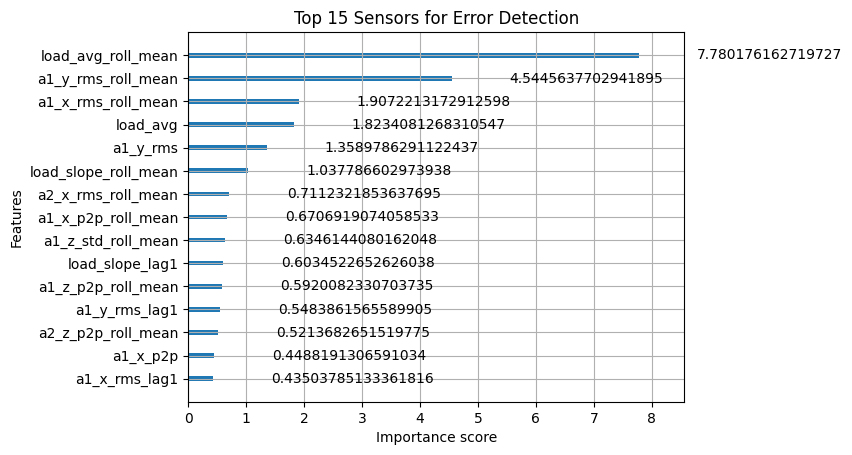

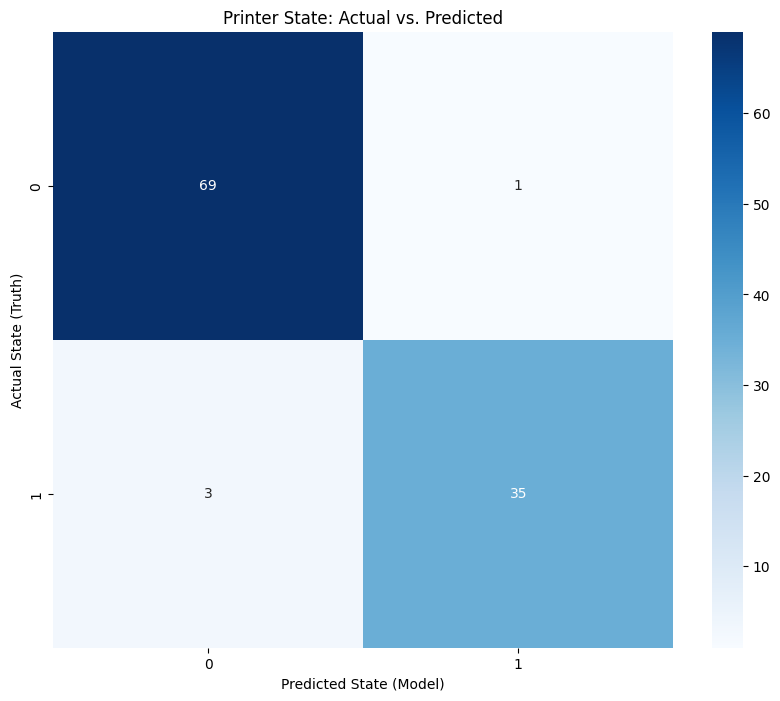

Generating Correlation Matrix...


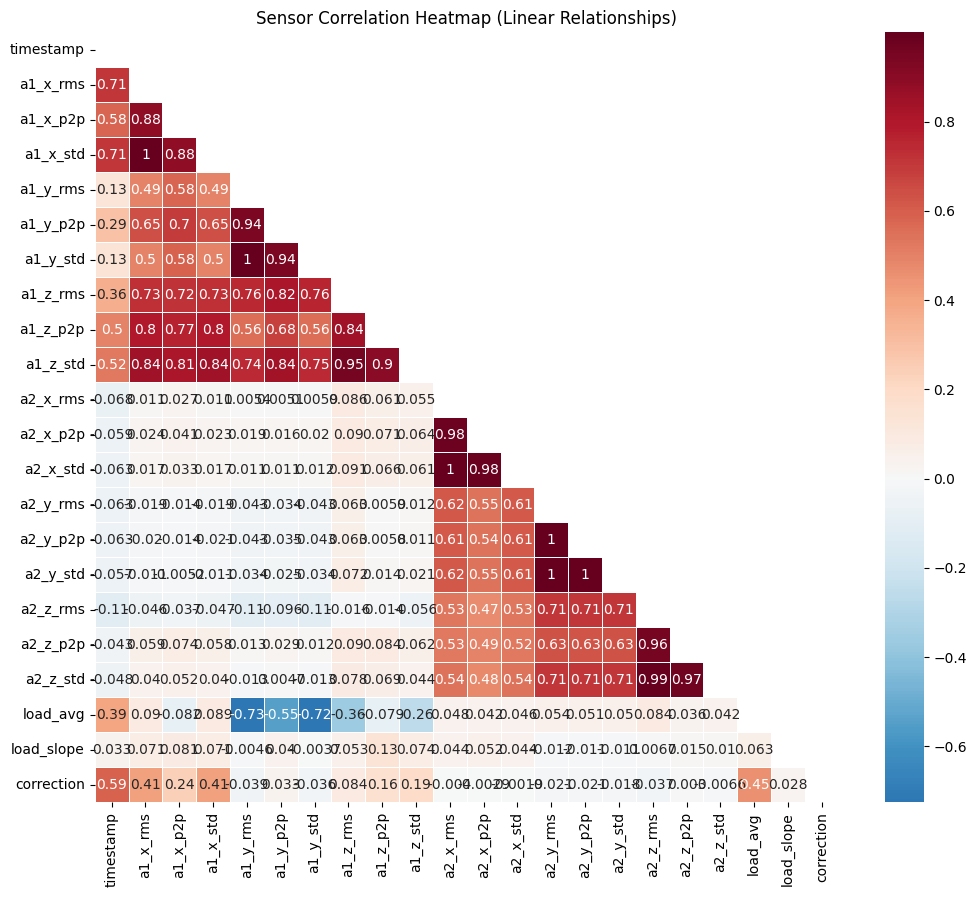


Model saved successfully as xgboost_printer_model.json


In [17]:
# Visualizations
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Sensors for Error Detection")
plt.show()

# --- Confusion Matrix Visualization ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predictions)

# Use the LabelEncoder classes to label the axes correctly
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=le.classes_, 
    yticklabels=le.classes_
)

plt.title("Printer State: Actual vs. Predicted")
plt.ylabel('Actual State (Truth)')
plt.xlabel('Predicted State (Model)')
plt.show()

# --- Correlation Matrix Visualization ---
print("Generating Correlation Matrix...")

# We only want to look at the relationship between raw sensors and the target
# Too many lag features will make the matrix huge and unreadable
cols_to_plot = [col for col in df.columns if 'lag' not in col and 'roll' not in col and col != 'relative_img_path']

plt.figure(figsize=(12, 10))
corr_matrix = df[cols_to_plot].corr()

# Create a mask to hide the top half (it's a mirror image of the bottom)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, # Set to True if you have < 10 sensors, False if you have many
    cmap='RdBu_r', # Red for negative correlation, Blue for positive
    center=0,
    linewidths=.5
)

plt.title("Sensor Correlation Heatmap (Linear Relationships)")
plt.show()

# --- 8. Saving ---
model_filename = "xgboost_printer_model.json"
best_model.save_model(model_filename)
print(f"\nModel saved successfully as {model_filename}")

Found 4 files. Processing individually...
Combined dataset size: (4071, 63)
Plotting Correlation Matrix...


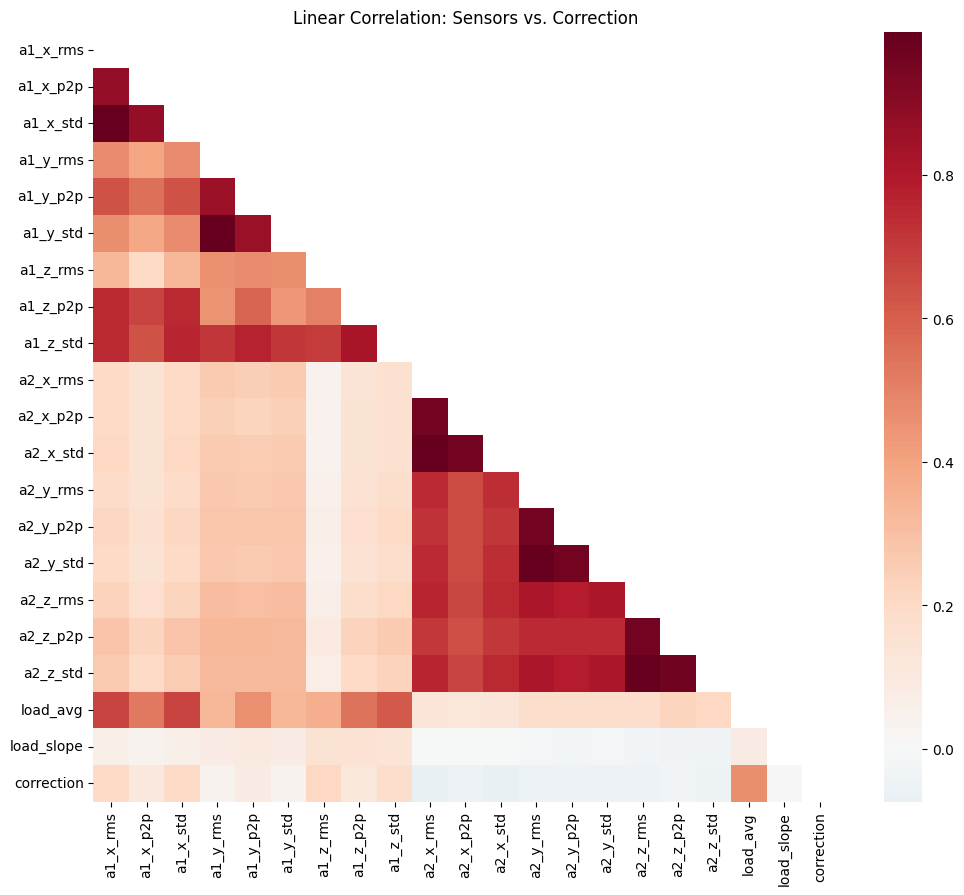

Tuning for 3 classes...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Final Model Report ---
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       535
           1       0.88      0.96      0.92       254
           2       0.86      0.69      0.77        26

    accuracy                           0.93       815
   macro avg       0.90      0.86      0.88       815
weighted avg       0.93      0.93      0.93       815



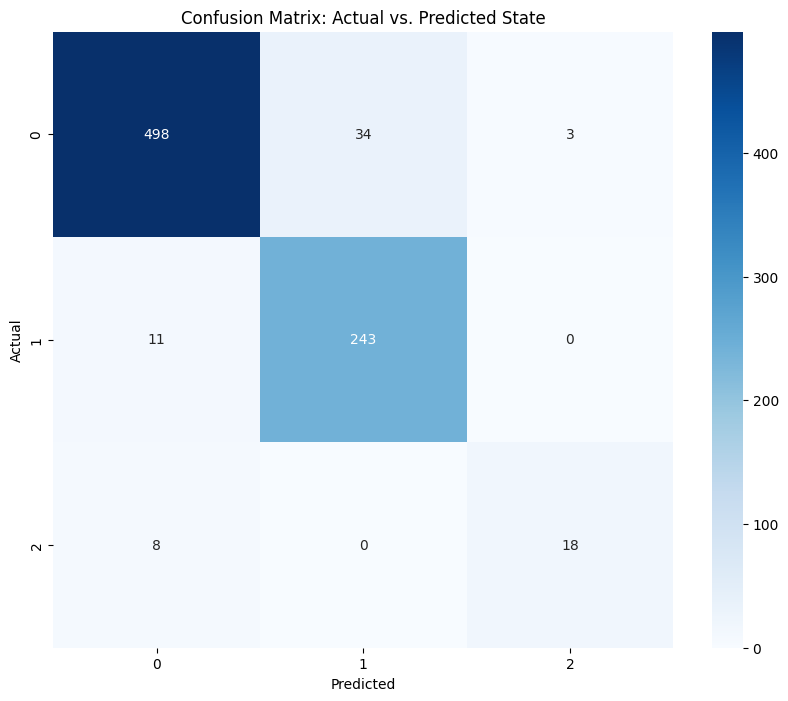

<Figure size 1000x800 with 0 Axes>

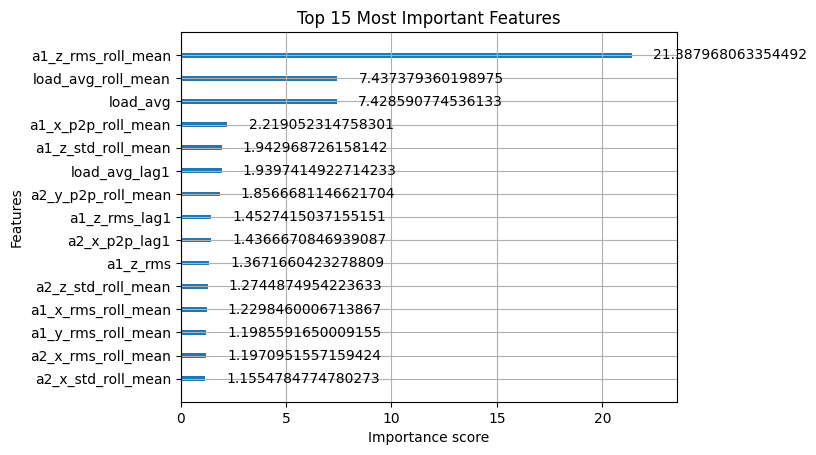


Model saved as xgboost_printer_model.json


In [28]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- 1. Data Loading & Individual Processing ---
path = "/home/ubuntu/m4bp-training/CleanedData" 
all_files = glob.glob(os.path.join(path, "*.csv"))

if not all_files:
    print(f"Error: No CSV files found in {path}")
    exit()

li = []
print(f"Found {len(all_files)} files. Processing individually...")

base_sensor_cols = [] # We save this to use in the correlation matrix later

for filename in all_files:
    temp_df = pd.read_csv(filename)
    
    # A. Sort by time so lags make sense
    if 'timestamp' in temp_df.columns:
        temp_df = temp_df.sort_values('timestamp').reset_index(drop=True)
    
    # B. Generate Features (INSIDE the loop prevents data bleed)
    exclude = ['relative_img_path', 'correction', 'timestamp']
    sensor_cols = [col for col in temp_df.columns if col not in exclude]
    
    if not base_sensor_cols:
        base_sensor_cols = sensor_cols # Grab the base column names
    
    new_features = []
    for col in sensor_cols:
        new_features.append(pd.DataFrame({
            f"{col}_lag1": temp_df[col].shift(1),
            f"{col}_roll_mean": temp_df[col].rolling(window=5).mean()
        }, index=temp_df.index))
    
    temp_df = pd.concat([temp_df] + new_features, axis=1)
    
    # C. Drop NaNs now so Print B doesn't see Print A's tail
    li.append(temp_df.dropna())

# Combine everything into one master dataframe
df = pd.concat(li, axis=0, ignore_index=True).copy()
print(f"Combined dataset size: {df.shape}")

# --- 2. Label Encoding ---
df['correction'] = df['correction'].fillna(0).astype(int)
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'])
num_classes = len(le.classes_)


# --- 3. Correlation Matrix (Diagnostic) ---
print("Plotting Correlation Matrix...")
plt.figure(figsize=(12, 10))
corr_cols = base_sensor_cols + ['correction']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False)
plt.title("Linear Correlation: Sensors vs. Correction")
plt.show()

# --- 4. Split and Weights ---
# NOW we drop the timestamp and paths for training
X = df.drop(columns=['timestamp', 'relative_img_path', 'correction'], errors='ignore')
y = df['correction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

# --- 5. Hyperparameter Tuning ---
print(f"Tuning for {num_classes} classes...")
clf = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=num_classes,
    tree_method='hist',
    random_state=42
)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

search = RandomizedSearchCV(
    clf, param_distributions=param_grid, n_iter=10, 
    scoring='f1_macro', cv=StratifiedKFold(n_splits=3), verbose=1, random_state=42
)

search.fit(X_train, y_train, sample_weight=weights)

# --- 6. Final Model (Probability Enabled) ---
best_params = search.best_params_
best_model = xgb.XGBClassifier(**best_params, objective='multi:softprob', num_class=num_classes)
best_model.fit(X_train, y_train, sample_weight=weights)

# --- 7. Evaluation & Confusion Matrix ---
probs = best_model.predict_proba(X_test)
predictions = np.argmax(probs, axis=1)

print("\n--- Final Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Actual vs. Predicted State")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



# --- 8. Feature Importance & Save ---
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Most Important Features")
plt.show()



best_model.save_model("xgboost_printer_model.json")
print("\nModel saved as xgboost_printer_model.json")

Found 8 files. Processing individually...
Combined dataset size: (8805, 64)

--- Data Health Check ---
Total Row Counts:
correction
0    5102
2    1275
1    1267
4    1161
Name: count, dtype: int64

Number of unique files containing each class:
correction
0    8
1    3
2    3
4    2
Name: file_id, dtype: int64
Plotting Correlation Matrix...


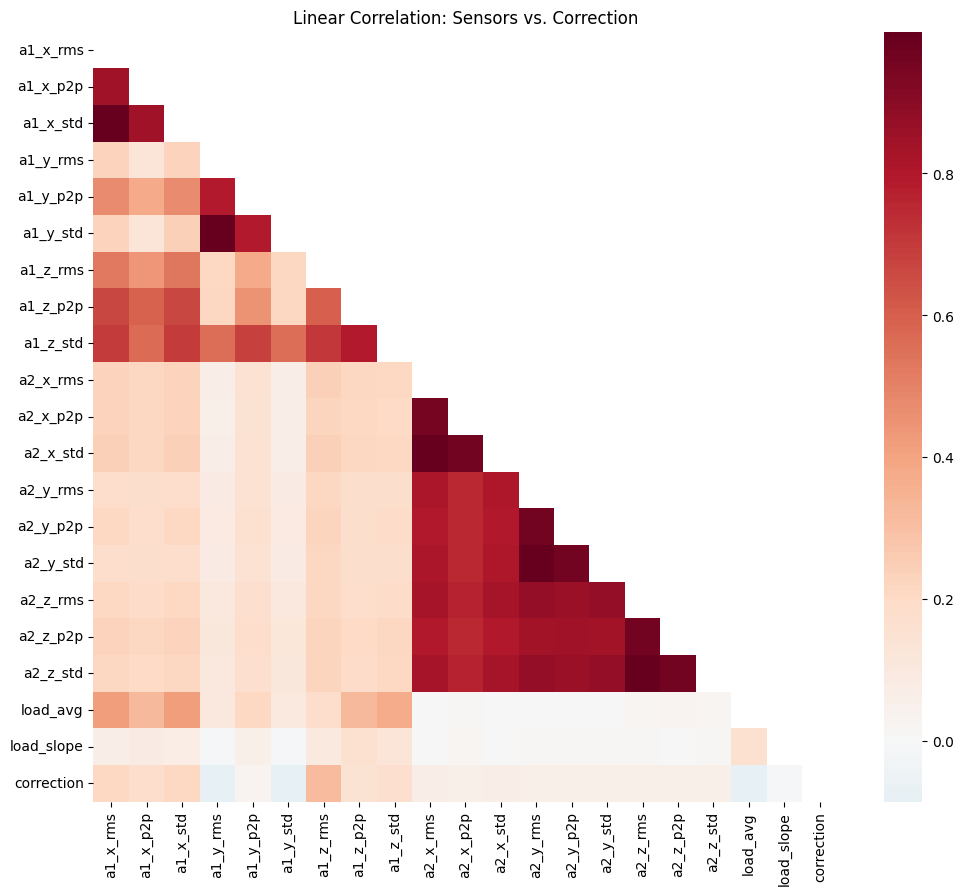

--- Reality Check: What is actually in each set? ---
Classes in Training Set: [0 1 2 3]
Classes in Test Set:     [0 1]
Tuning for 4 classes...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Final Model Report ---


ValueError: Number of classes, 2, does not match size of target_names, 4. Try specifying the labels parameter

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- 1. Data Loading & Individual Processing ---
path = "/home/ubuntu/m4bp-training/CleanedData" 
all_files = glob.glob(os.path.join(path, "*.csv"))

if not all_files:
    print(f"Error: No CSV files found in {path}")
    exit()

li = []
print(f"Found {len(all_files)} files. Processing individually...")

base_sensor_cols = [] 

for filename in all_files:
    temp_df = pd.read_csv(filename)
    
    # Skip files that are too short for our rolling window
    if len(temp_df) < 5:
        print(f"Skipping {os.path.basename(filename)}: fewer than 5 rows.")
        continue

    # Tag the file ID so we can group our train/test splits later
    temp_df['file_id'] = filename
    
    # A. Sort by time so lags make sense
    if 'timestamp' in temp_df.columns:
        temp_df = temp_df.sort_values('timestamp').reset_index(drop=True)
        
    # Handle NaNs in the target variable BEFORE dropping anything
    if 'correction' in temp_df.columns:
        temp_df['correction'] = temp_df['correction'].fillna(0)
    
    # B. Generate Features
    exclude = ['relative_img_path', 'correction', 'timestamp', 'file_id']
    sensor_cols = [col for col in temp_df.columns if col not in exclude]
    
    if not base_sensor_cols:
        base_sensor_cols = sensor_cols 
    
    new_features = []
    for col in sensor_cols:
        new_features.append(pd.DataFrame({
            f"{col}_lag1": temp_df[col].shift(1),
            f"{col}_roll_mean": temp_df[col].rolling(window=5).mean()
        }, index=temp_df.index))
    
    temp_df = pd.concat([temp_df] + new_features, axis=1)
    
    # C. Drop NaNs (from the lag/rolling features) safely
    li.append(temp_df.dropna())

# Combine everything into one master dataframe
df = pd.concat(li, axis=0, ignore_index=True).copy()
print(f"Combined dataset size: {df.shape}")

# --- DIAGNOSTIC: Check Class Distribution across Files ---
print("\n--- Data Health Check ---")
class_counts = df['correction'].value_counts()
print(f"Total Row Counts:\n{class_counts}")

# Count how many unique files contain at least one instance of each class
file_counts = df.groupby('correction')['file_id'].nunique()
print(f"\nNumber of unique files containing each class:\n{file_counts}")

if file_counts.min() < 2:
    print("\nWARNING: Some classes appear in only ONE file.")
    print("These classes can NEVER be in both Train and Test sets simultaneously.")

# --- 2. Label Encoding ---
df['correction'] = df['correction'].astype(int)
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'])
num_classes = len(le.classes_)

# --- 3. Correlation Matrix (Diagnostic) ---
print("Plotting Correlation Matrix...")
plt.figure(figsize=(12, 10))
corr_cols = base_sensor_cols + ['correction']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False)
plt.title("Linear Correlation: Sensors vs. Correction")
plt.show()

# --- 4. Split and Weights (Stratified & Grouped) ---
X = df.drop(columns=['timestamp', 'relative_img_path', 'correction', 'file_id'], errors='ignore')
y = df['correction']
groups = df['file_id'] # Extract our group tags

# NEW: Use StratifiedGroupKFold to balance classes while keeping files intact.
# n_splits=5 gives us an 80/20 train/test split.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("--- Reality Check: What is actually in each set? ---")
print(f"Classes in Training Set: {np.unique(y_train)}")
print(f"Classes in Test Set:     {np.unique(y_test)}")

# --- 5. Hyperparameter Tuning ---
print(f"Tuning for {num_classes} classes...")

# FIXED: Reverted to multi:softmax so sklearn scoring doesn't crash
clf = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=num_classes,
    tree_method='hist',
    random_state=42
)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# Use GroupKFold to respect file boundaries during cross-validation
search = RandomizedSearchCV(
    clf, param_distributions=param_grid, n_iter=10, 
    scoring='f1_macro', cv=GroupKFold(n_splits=3), verbose=1, random_state=42
)

# Pass the groups into the fit method
search.fit(X_train, y_train, groups=groups_train, sample_weight=weights)

# --- 6. Final Model ---
# RandomizedSearchCV automatically refits on the whole training set. 
best_model = search.best_estimator_

# --- 7. Evaluation & Confusion Matrix ---
probs = best_model.predict_proba(X_test)
predictions = np.argmax(probs, axis=1)

print("\n--- Final Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Actual vs. Predicted State")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- 8. Feature Importance & Save ---
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Most Important Features")
plt.show()

best_model.save_model("xgboost_printer_model.json")
print("\nModel saved as xgboost_printer_model.json")

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- 1. Data Loading & Individual Processing ---
path = "/home/ubuntu/m4bp-training/CleanedData" 
all_files = glob.glob(os.path.join(path, "**/log2.csv"), recursive=True)

if not all_files:
    print(f"Error: No CSV files found in {path}")
    exit()

li = []
print(f"Found {len(all_files)} files. Processing individually...")

base_sensor_cols = [] 

for filename in all_files:
    temp_df = pd.read_csv(filename)
    
    # Skip files that are too short for our rolling window
    if len(temp_df) < 5:
        print(f"Skipping {os.path.basename(filename)}: fewer than 5 rows.")
        continue

    # Tag the file ID so we can group our train/test splits later
    temp_df['file_id'] = filename
    
    # A. Sort by time so lags make sense
    if 'timestamp' in temp_df.columns:
        temp_df = temp_df.sort_values('timestamp').reset_index(drop=True)
        
    # Handle NaNs in the target variable BEFORE dropping anything
    if 'correction' in temp_df.columns:
        temp_df['correction'] = temp_df['correction'].fillna(0)
    
    # B. Generate Features
    exclude = ['relative_img_path', 'correction', 'timestamp', 'file_id']
    sensor_cols = [col for col in temp_df.columns if col not in exclude]
    
    if not base_sensor_cols:
        base_sensor_cols = sensor_cols 
    
    new_features = []
    for col in sensor_cols:
        new_features.append(pd.DataFrame({
            f"{col}_lag1": temp_df[col].shift(1),
            f"{col}_roll_mean": temp_df[col].rolling(window=5).mean()
        }, index=temp_df.index))
    
    temp_df = pd.concat([temp_df] + new_features, axis=1)
    
    # C. Drop NaNs (from the lag/rolling features) safely
    li.append(temp_df.dropna())

# Combine everything into one master dataframe
df = pd.concat(li, axis=0, ignore_index=True).copy()
print(f"Combined dataset size: {df.shape}")

# --- DIAGNOSTIC: Check Class Distribution across Files ---
print("\n--- Data Health Check ---")
class_counts = df['correction'].value_counts()
print(f"Total Row Counts:\n{class_counts}")

# Count how many unique files contain at least one instance of each class
file_counts = df.groupby('correction')['file_id'].nunique()
print(f"\nNumber of unique files containing each class:\n{file_counts}")

if file_counts.min() < 2:
    print("\nWARNING: Some classes appear in only ONE file.")
    print("These classes can NEVER be in both Train and Test sets simultaneously.")

# --- 2. Label Encoding ---
df['correction'] = df['correction'].astype(int)
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'])
num_classes = len(le.classes_)

# --- 3. Correlation Matrix (Diagnostic) ---
print("Plotting Correlation Matrix...")
plt.figure(figsize=(12, 10))
corr_cols = base_sensor_cols + ['correction']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False)
plt.title("Linear Correlation: Sensors vs. Correction")
plt.show()

# --- 4. Split and Weights (Stratified & Grouped) ---
X = df.drop(columns=['timestamp', 'relative_img_path', 'correction', 'file_id'], errors='ignore')
y = df['correction']
groups = df['file_id'] # Extract our group tags

# NEW: Use StratifiedGroupKFold to balance classes while keeping files intact.
# n_splits=5 gives us an 80/20 train/test split.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("--- Reality Check: What is actually in each set? ---")
print(f"Classes in Training Set: {np.unique(y_train)}")
print(f"Classes in Test Set:     {np.unique(y_test)}")

# --- 5. Hyperparameter Tuning ---
print(f"Tuning for {num_classes} classes...")

# FIXED: Reverted to multi:softmax so sklearn scoring doesn't crash
clf = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=num_classes,
    tree_method='hist',
    random_state=42
)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# Use GroupKFold to respect file boundaries during cross-validation
search = RandomizedSearchCV(
    clf, param_distributions=param_grid, n_iter=10, 
    scoring='f1_macro', cv=GroupKFold(n_splits=3), verbose=1, random_state=42
)

# Pass the groups into the fit method
search.fit(X_train, y_train, groups=groups_train, sample_weight=weights)

# --- 6. Final Model ---
# RandomizedSearchCV automatically refits on the whole training set. 
best_model = search.best_estimator_

# --- 7. Evaluation & Confusion Matrix ---
probs = best_model.predict_proba(X_test)
predictions = np.argmax(probs, axis=1)

print("\n--- Final Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Actual vs. Predicted State")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- 8. Feature Importance & Save ---
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, max_num_features=15, importance_type='gain')
plt.title("Top 15 Most Important Features")
plt.show()

best_model.save_model("xgboost_printer_model.json")
print("\nModel saved as xgboost_printer_model.json")